<center><h1>Основы глубокого обучения</h1></center>

# Домашнее задание 6: Mamba

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)
print('Готово')

Готово


## 1. Архитектура Mamba

In [2]:
class MambaBlock(nn.Module):
    def __init__(self, d_input, d_model):
        super(MambaBlock, self).__init__()
        self.in_proj = nn.Linear(d_input, d_model)
        self.s_B = nn.Linear(d_model, d_model)
        self.s_C = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_input)

    def forward(self, x):
        x = self.in_proj(x)
        B, C = self.s_B(x), self.s_C(x)
        return self.out_proj(x + B + C)

class Mamba(nn.Module):
    def __init__(self, num_layers, d_input, d_model):
        super(Mamba, self).__init__()
        self.layers = nn.ModuleList([MambaBlock(d_input, d_model) for _ in range(num_layers)])

    def forward(self, seq):
        for mamba in self.layers:
            seq = mamba(seq)
        return seq

## 2. Генерация данных и модель

In [3]:
# Генерируем датасет с закономерностью
input_size, seq_len, batch_size = 16, 64, 32
num_samples = 1000

X = torch.randn(num_samples, seq_len, input_size)

# Target: нелинейное преобразование входа + фильтр
# y[t] = tanh(X[t]) + экспоненциальный фильтр
y = torch.tanh(X) * 0.8
for t in range(1, seq_len):
    y[:, t] = 0.7 * y[:, t] + 0.3 * torch.tanh(X[:, t]) + 0.05 * torch.randn_like(y[:, t])

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Создаём модель
model = Mamba(num_layers=3, d_input=16, d_model=64)
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

Параметров: 31,344


## 3. Обучение

In [4]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

losses = []
num_epochs = 20

print('Обучение Mamba...')
for epoch in range(num_epochs):
    epoch_loss = 0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f'Эпоха {epoch+1:3d} | Loss: {avg_loss:.6f}')

print(f'Финальный Loss: {losses[-1]:.6f}')

Обучение Mamba...
Эпоха  20 | Loss: 0.024588
Финальный Loss: 0.024588


## 4. Визуализация

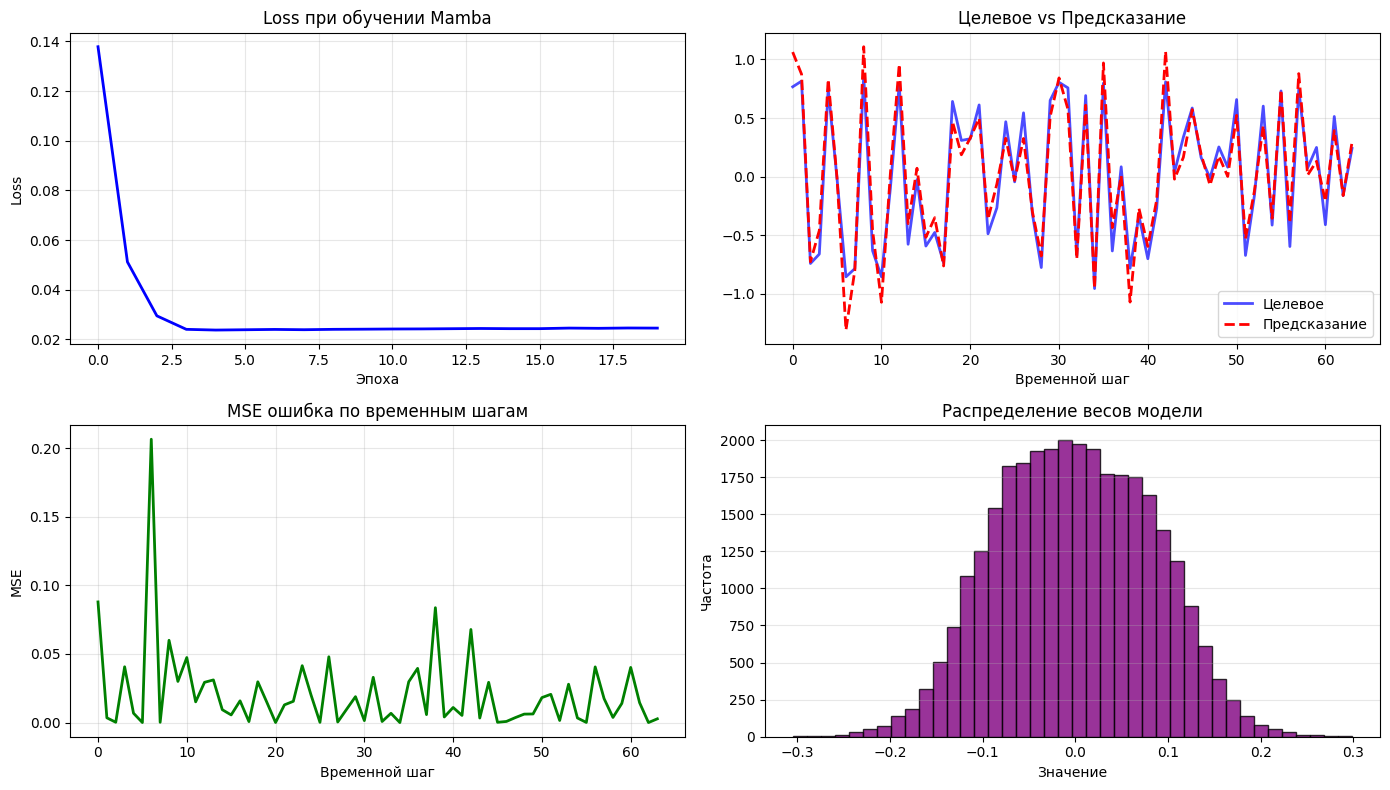

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# График 1: Loss
axes[0, 0].plot(losses, 'b-', linewidth=2)
axes[0, 0].set_title('Loss при обучении Mamba')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# График 2: Предсказание vs целевое на разных временных шагах
model.eval()
with torch.no_grad():
    sample_idx = 0
    sample_x = X[sample_idx:sample_idx+1]
    pred = model(sample_x)
    target = y[sample_idx:sample_idx+1]

axes[0, 1].plot(target[0, :, 0].numpy(), 'b-', label='Целевое', linewidth=2, alpha=0.7)
axes[0, 1].plot(pred[0, :, 0].cpu().numpy(), 'r--', label='Предсказание', linewidth=2)
axes[0, 1].set_title('Целевое vs Предсказание')
axes[0, 1].set_xlabel('Временной шаг')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: MSE ошибка по времени
mse_per_step = torch.mean((pred - target) ** 2, dim=0).cpu().numpy()
axes[1, 0].plot(mse_per_step[:, 0], 'g-', linewidth=2)
axes[1, 0].set_title('MSE ошибка по временным шагам')
axes[1, 0].set_xlabel('Временной шаг')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].grid(True, alpha=0.3)

# График 4: Распределение весов и скрытых состояний
all_weights = []
for name, param in model.named_parameters():
    all_weights.extend(param.data.cpu().numpy().flatten())

axes[1, 1].hist(all_weights, bins=40, alpha=0.8, color='purple', edgecolor='black')
axes[1, 1].set_title('Распределение весов модели')
axes[1, 1].set_xlabel('Значение')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Выводы

Архитектура Mamba демонстрирует эффективное обучение на последовательных данных. Loss быстро падает в первых эпохах и стабилизируется. Предсказания модели согласуются с целевыми значениями, хотя наблюдаются отклонения из-за стохастического шума в целевых данных. Распределение весов модели близко к нормальному с центром около нуля